In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Missing value - there is missing value in the "TotalCharges" column

Data type - data type of the "TotalCharges" should be changed into int

replacing the empty string in the "TotalChargees" into nan value

In [7]:
df["TotalCharges"] = df["TotalCharges"].replace(" " , np.nan)

changing the data type of the "TotalCharges" column

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

# Exploratory data analysis of the data

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

distribution of the churn

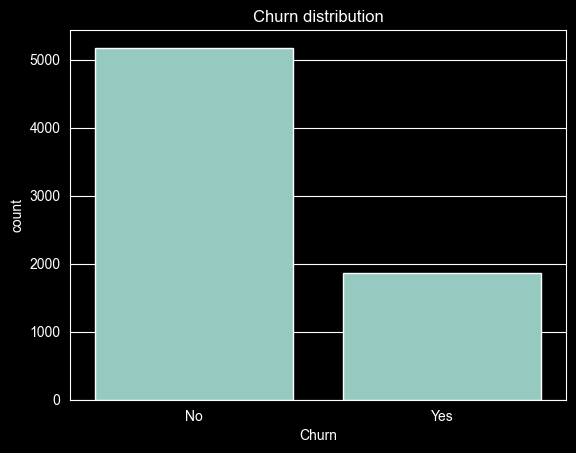

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
plt.figure()
sns.countplot(data = df , x = "Churn" )
plt.title("Churn distribution")
plt.show()
df["Churn"].value_counts()

Customer retentation - large amount of the customer continue.

Churn rate - some of the customer have left the service so there is the area of improvement

how many customer are there in each contract type

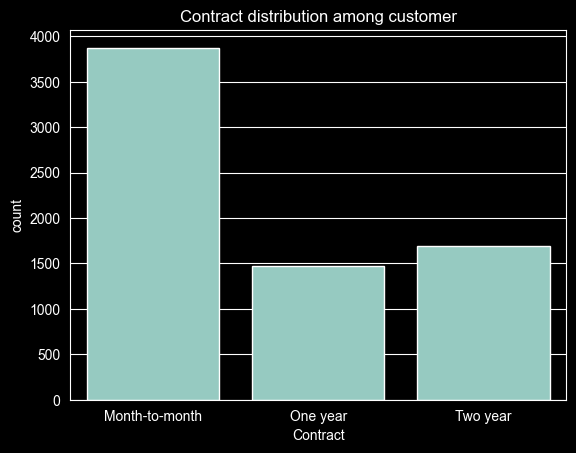

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [11]:
plt.figure()
sns.countplot(data = df , x = "Contract")
plt.title("Contract distribution among customer")
plt.show()
df["Contract"].value_counts()

Most of the coustomer are in the Month to Month contract

distribution of the internet service

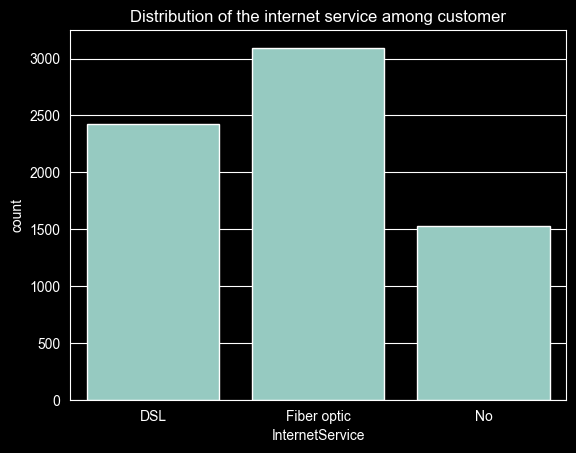

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [12]:
plt.figure()
sns.countplot(data = df , x = "InternetService")
plt.title("Distribution of the internet service among customer")
plt.show()
df["InternetService"].value_counts()

Most of the customer have fiber optic in the internet service and then customer have dsl as the internet service and few customer dont have a internet service

distribution of tenure

<function matplotlib.pyplot.show(close=None, block=None)>

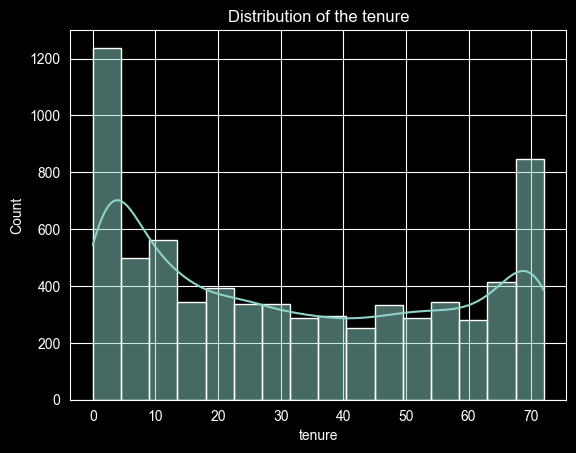

In [13]:
plt.figure()
sns.histplot(df["tenure"] , kde = True)
plt.title("Distribution of the tenure")
plt.show

distribution of the monthly charges

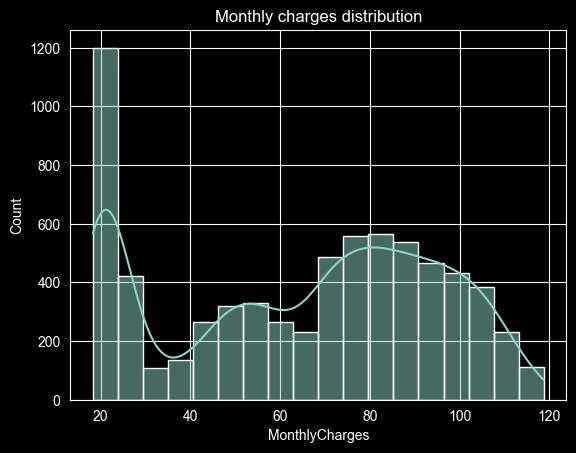

In [14]:
plt.figure()
sns.histplot(df["MonthlyCharges"] , kde = True)
plt.title("Monthly charges distribution")
plt.show()

distribution of the totalcharges

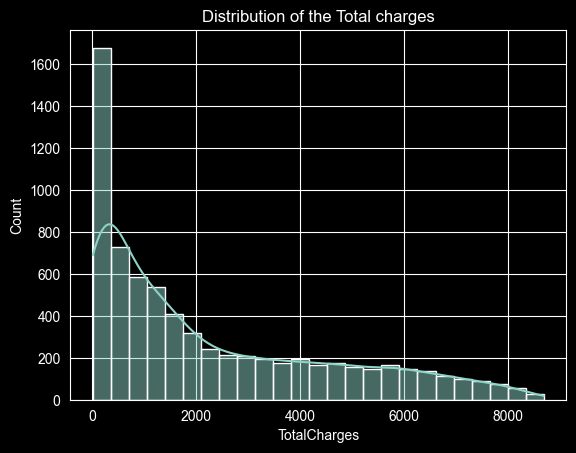

In [15]:
plt.figure()
sns.histplot(df["TotalCharges"] , kde = True)
plt.title("Distribution of the Total charges")
plt.show()

vary of the churn among the different contract type

<Axes: xlabel='Contract', ylabel='count'>

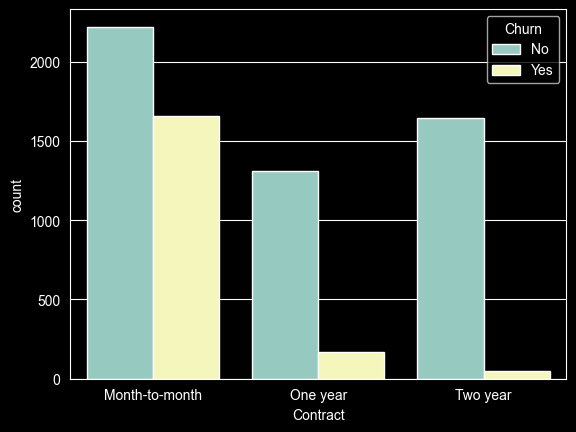

In [16]:
plt.figure()
sns.countplot(data = df ,  x = "Contract" , hue = "Churn")

short time of a contract have a more customer churn this indicate that the new customer have a short contract

how does the internet service changes as the churn

<Axes: xlabel='InternetService', ylabel='count'>

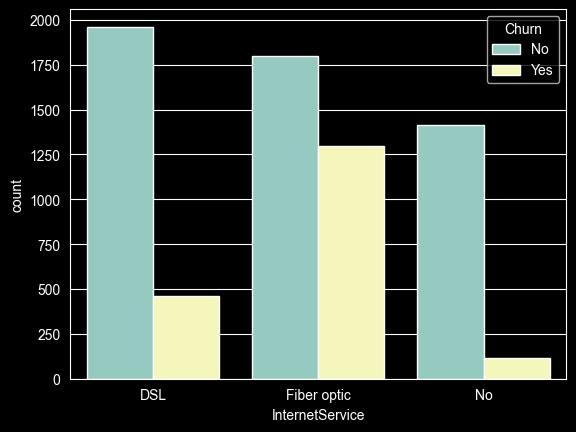

In [17]:
plt.figure()
sns.countplot(data = df , x = "InternetService" , hue = "Churn")

customer those who dont have a internet service might have a phone service and most of the customer who dont have the internet service have not churned and most of the customer that have a internet service have churned

distribution of the tenure and the churn

Text(0.5, 1.0, 'Distribution of tenure as per the customer churn')

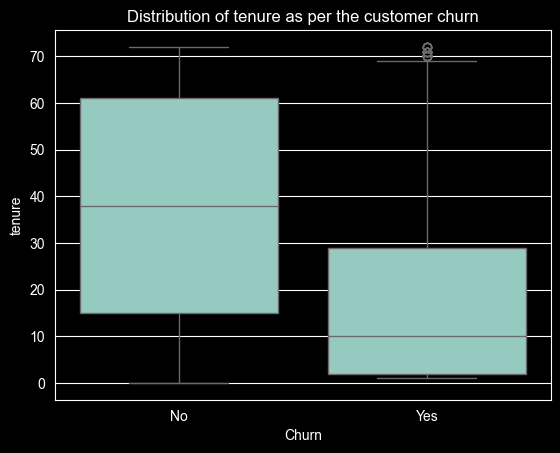

In [18]:
plt.figure()
sns.boxplot(data = df , x = "Churn" , y = "tenure")
plt.title("Distribution of tenure as per the customer churn")

most of the customer that have churned have a less tenure as compareds to the customer that have not churned

distribution of the monthly charges as per the churn

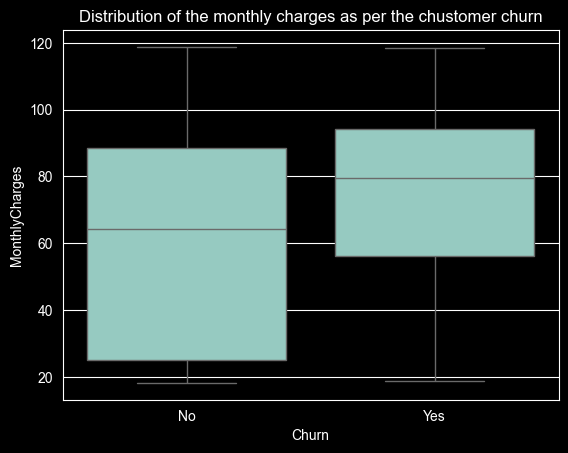

In [19]:
plt.figure()
sns.boxplot(data = df , x = "Churn" , y = "MonthlyCharges")
plt.title("Distribution of the monthly charges as per the chustomer churn")
plt.show()

Distribution of the total charges as per the customer churn

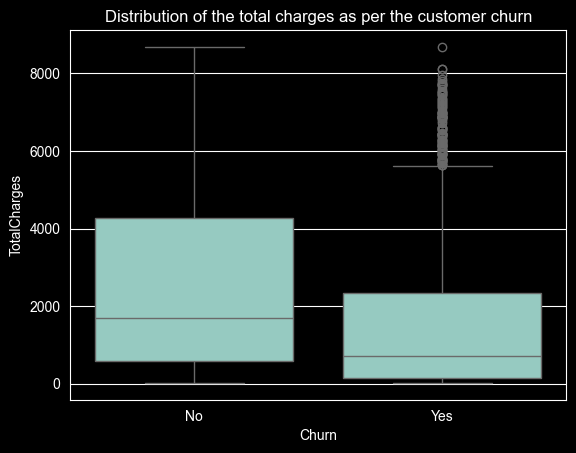

In [20]:
plt.figure()
sns.boxplot(data = df , x = "Churn" , y = "TotalCharges")
plt.title("Distribution of the total charges as per the customer churn")
plt.show()

most of the customer that have churned have a lower total charges this indicates that there are new customer who have churned and alos there are outliners in the churned customer weho have a higher total charges and this also indicates that there are the old customer who have churned

# Feature of the data

In [21]:
x = df.drop(["Churn" , "customerID"] , axis = 1)
y = df["Churn"]

split the data

In [22]:
from sklearn.model_selection import train_test_split
X_train  , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

seperating the columns by the type

In [23]:
num_col = X_train.select_dtypes(include = ["int64" , "float64"]).columns
cate_col = X_train.select_dtypes(include = "object").columns

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8336\2684373093.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cate_col = X_train.select_dtypes(include = "object").columns


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy = "median")),
    ("scaler" , StandardScaler())
])
cate_pipeline = Pipeline([
    ("encoder" , OneHotEncoder(handle_unknown = "ignore" , sparse_output = False))
])
from sklearn.compose import ColumnTransformer
transform = ColumnTransformer(transformers = [
    ("nums" , num_pipeline , num_col),
    ("cate" , cate_pipeline , cate_col)
] , remainder = "passthrough")

X_train_processed_raw = transform.fit_transform(X_train)
X_test_processed_raw = transform.transform(X_test)

from sklearn.decomposition import PCA

pca = PCA(n_components = 0.9999999999999999)

X_train_processed = pca.fit_transform(X_train_processed_raw)
X_test_processed = pca.transform(X_test_processed_raw)

In [25]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_train_processed = encoder.fit_transform(y_train)
y_test_processed = encoder.transform(y_test)

In [26]:
X_train_processed

array([[-4.68716317e-01, -1.76629415e-01, -1.14964210e+00, ...,
        -9.36750677e-17,  4.44089210e-16,  4.99600361e-16],
       [ 2.14672056e+00,  4.01646559e-01,  1.17510758e-02, ...,
        -5.27355937e-15,  2.41473508e-15, -1.85962357e-15],
       [-1.46550840e+00, -1.87274425e+00, -1.11049662e+00, ...,
        -3.11556336e-15,  5.55111512e-16, -2.20656826e-15],
       ...,
       [-2.79699404e+00,  8.69288287e-01,  5.28548467e-01, ...,
         2.35228503e-15, -2.16493490e-15, -5.96744876e-16],
       [ 1.18203868e+00, -2.07448781e+00,  2.26018695e+00, ...,
        -1.06165077e-15,  8.32667268e-16,  2.63677968e-16],
       [-2.86575368e+00,  1.38836540e+00,  5.41273822e-01, ...,
        -5.48172618e-16, -1.66533454e-16, -3.88578059e-16]],
      shape=(5634, 45))

In [28]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train_processed , y_train_processed)
y_pred = lr.predict(X_test_processed)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test_processed , y_pred)
accuracy

0.8211497515968772